## Data load and information

In [1]:
#Install necessary packages first:
!pip install torch torchvision torchaudio transformers accelerate bitsandbytes huggingface_hub scikit-learn pandas numpy matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.5 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load your dataset
import pandas as pd

# Replace with your actual file path in Google Drive
df = pd.read_csv('/content/drive/MyDrive/Group Assignment Group6/final_preprocessed.csv')

# Check if loaded correctly
print(df.head())
print(df.shape)

Mounted at /content/drive
   Age  Education  EmploymentLengthYears  MonthlyIncome  Dependents  \
0   59        1.0                     11    9067.159786           2   
1   51        0.0                     24    5068.058742           1   
2   24        3.0                      0    2557.541824           0   
3   25        3.0                      0    7535.097299           0   
4   25        4.0                      5    4798.465251           2   

   CreditScore  ExistingLoans  MonthlyDebt  YearsWithBank  HasSavingsAccount  \
0          770              3  1583.065500              7                  1   
1          698              3  1332.052087              7                  1   
2          480              1   911.536097              2                  1   
3          774              1   514.141526              6                  1   
4          590              4  2386.488285              3                  0   

   ...  LoanPurpose_Education  LoanPurpose_Home Improvement  \
0  

In [3]:
# Check data
print(df.info())  # Check data types
print(df.isnull().sum())  # Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Age                                  1000 non-null   int64  
 1   Education                            1000 non-null   float64
 2   EmploymentLengthYears                1000 non-null   int64  
 3   MonthlyIncome                        1000 non-null   float64
 4   Dependents                           1000 non-null   int64  
 5   CreditScore                          1000 non-null   int64  
 6   ExistingLoans                        1000 non-null   int64  
 7   MonthlyDebt                          1000 non-null   float64
 8   YearsWithBank                        1000 non-null   int64  
 9   HasSavingsAccount                    1000 non-null   int64  
 10  HasCheckingAccount                   1000 non-null   int64  
 11  LoanAmount                     

In [4]:
# Check the distribution of the target variable
default_counts = df['LoanDefault'].value_counts()
default_percentages = df['LoanDefault'].value_counts(normalize=True) * 100

print("LoanDefault Value Counts:")
print(default_counts)
print("\nLoanDefault Value Percentages:")
print(default_percentages)

LoanDefault Value Counts:
LoanDefault
0    500
1    500
Name: count, dtype: int64

LoanDefault Value Percentages:
LoanDefault
0    50.0
1    50.0
Name: proportion, dtype: float64


This indicates that 50% of the data has value of 1 for LoanDefault and 0 for the remaining.

## Decision Tree Model Training

Features used: ['Age', 'Education', 'EmploymentLengthYears', 'MonthlyIncome', 'Dependents', 'CreditScore', 'ExistingLoans', 'MonthlyDebt', 'YearsWithBank', 'HasSavingsAccount', 'HasCheckingAccount', 'LoanAmount', 'LoanTermMonths', 'InterestRate', 'Sentiment_Score', 'EmploymentType_Full-Time', 'EmploymentType_Part-Time', 'EmploymentType_Self-Employed', 'EmploymentType_Unemployed', 'EmploymentSector_Education', 'EmploymentSector_Finance', 'EmploymentSector_Government', 'EmploymentSector_Healthcare', 'EmploymentSector_Manufacturing', 'EmploymentSector_Other', 'EmploymentSector_Retail', 'EmploymentSector_Services', 'EmploymentSector_Technology', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'PropertyOwnership_Own Outright', 'PropertyOwnership_Own with Mortgage', 'PropertyOwnership_Rent', 'LoanPurpose_Car Loan', 'LoanPurpose_Debt Consolidation', 'LoanPurpose_Education', 'LoanPurpose_Home Improvement', 'LoanPurpose_Home Purchase', 'LoanPurpose_Medical', 'LoanPurpo

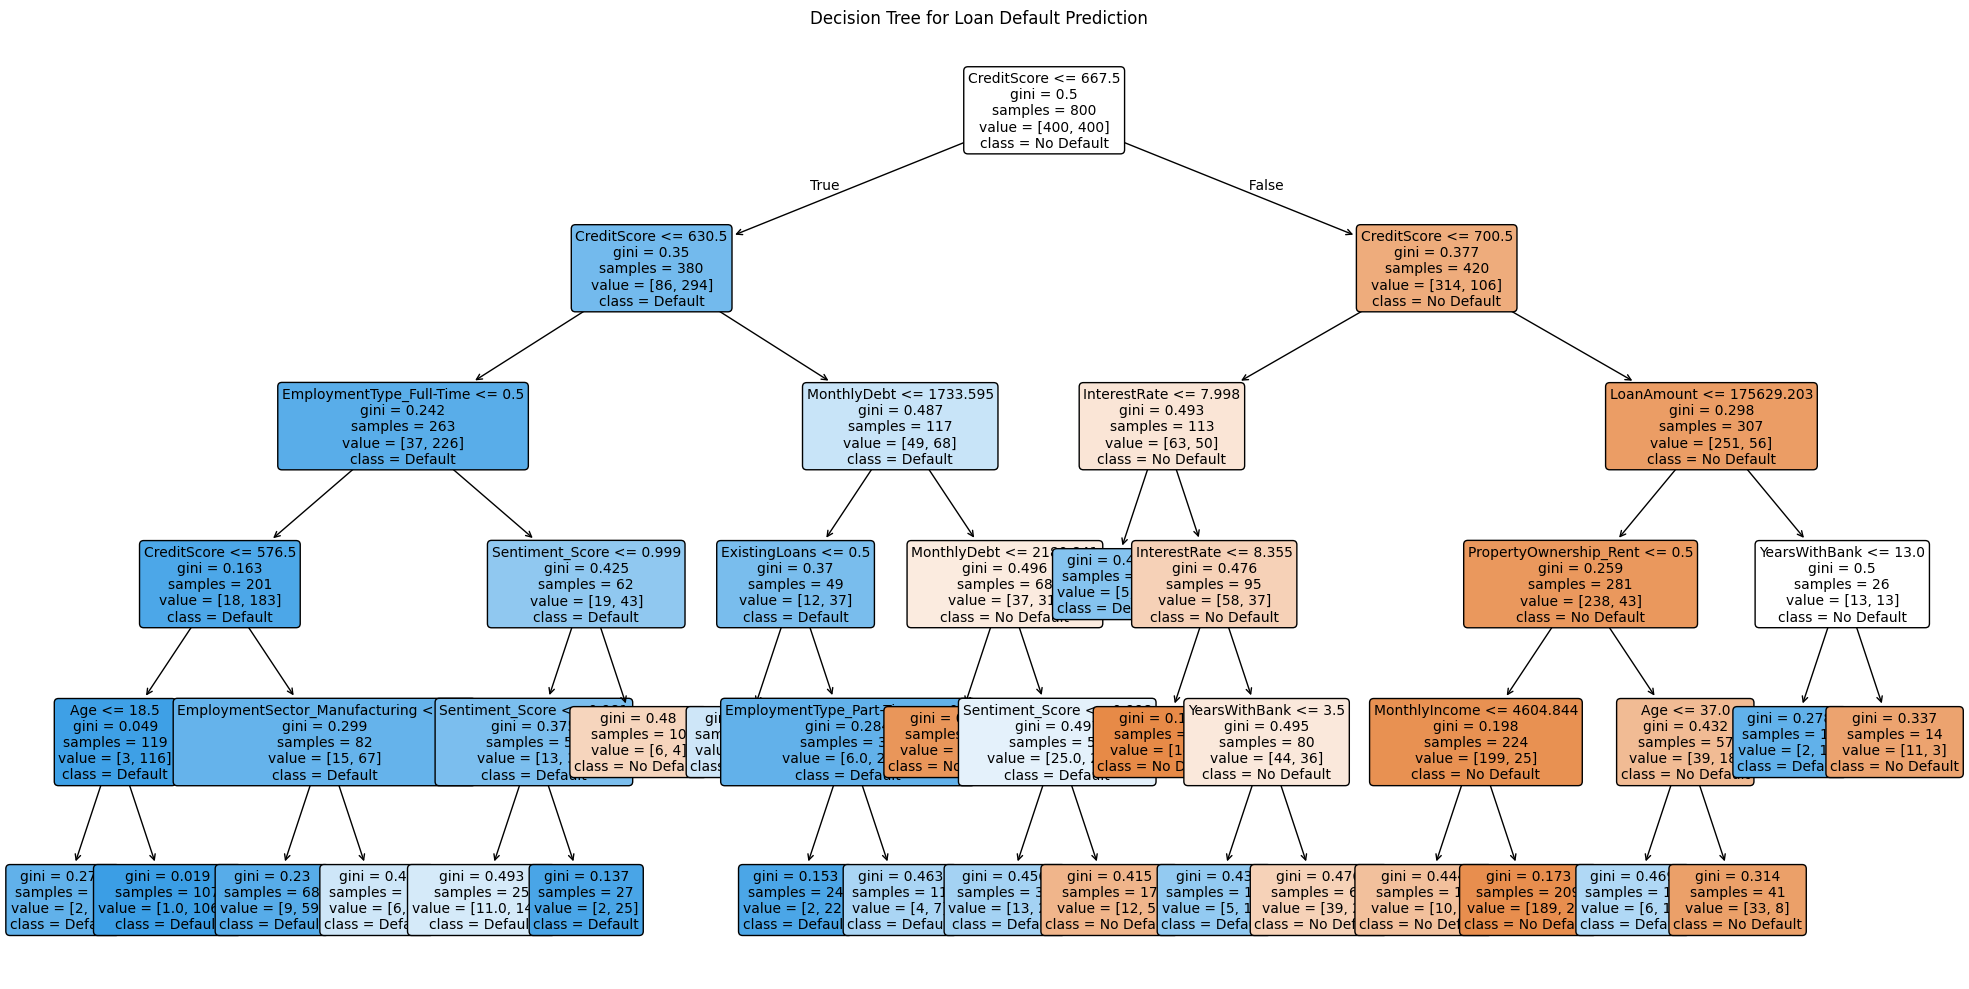

<Figure size 1000x800 with 0 Axes>

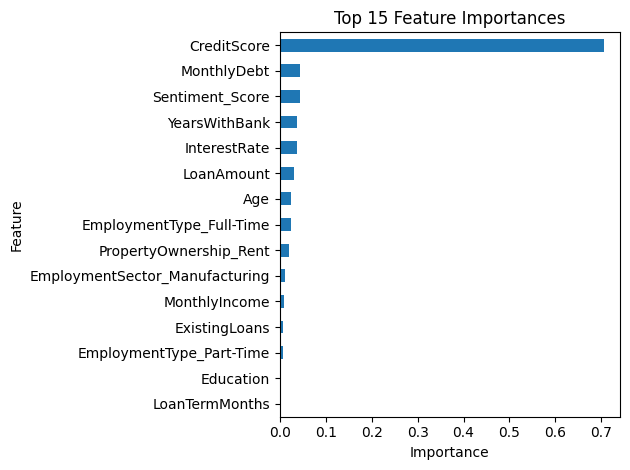

In [5]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Separate features (X) and target (y)
X = df.drop(['LoanDefault', 'LoanPurposeDescription'], axis=1)  # Drop target and text column
y = df['LoanDefault']

print("Features used:", X.columns.tolist())
print(f"\nNumber of features: {X.shape[1]}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures balanced split
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Train Decision Tree Classifier
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10
)

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

# Display Decision Tree Rules
print("\n" + "="*50)
print("DECISION TREE RULES")
print("="*50)
rules = export_text(model, feature_names=list(X.columns))
print(rules)

# Feature Importance
print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Loan Default Prediction")
plt.tight_layout()
plt.show()

# Visualize Feature Importance
plt.figure(figsize=(10, 8))
feature_importance.head(15).plot(x='Feature', y='Importance', kind='barh', legend=False)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Evaluation Metrics

📊 DECISION TREE MODEL EVALUATION - BASELINE MODEL

🔹 TRAINING SET PERFORMANCE:
   Accuracy: 0.8163 (81.62%)

🔹 TESTING SET PERFORMANCE:
   Accuracy:  0.6750 (67.50%)
   Precision: 0.6471 (64.71%)
   Recall:    0.7700 (77.00%)
   F1-Score:  0.7032 (70.32%)
   ROC-AUC:   0.7576 (75.76%)

🔍 MODEL FIT ANALYSIS
Training Accuracy:   0.8163
Testing Accuracy:    0.6750
Accuracy Gap:        0.1412

⚠️  WARNING: Possible OVERFITTING detected (gap > 10%)
   → Model may be too complex for the data
   → Consider: reducing max_depth or increasing min_samples_split

📈 CONFUSION MATRIX

True Negatives (TN):    58 | Correctly predicted NO default
False Positives (FP):   42 | Predicted default but actually NO default
False Negatives (FN):   23 | Predicted NO default but actually defaulted
True Positives (TP):    77 | Correctly predicted default


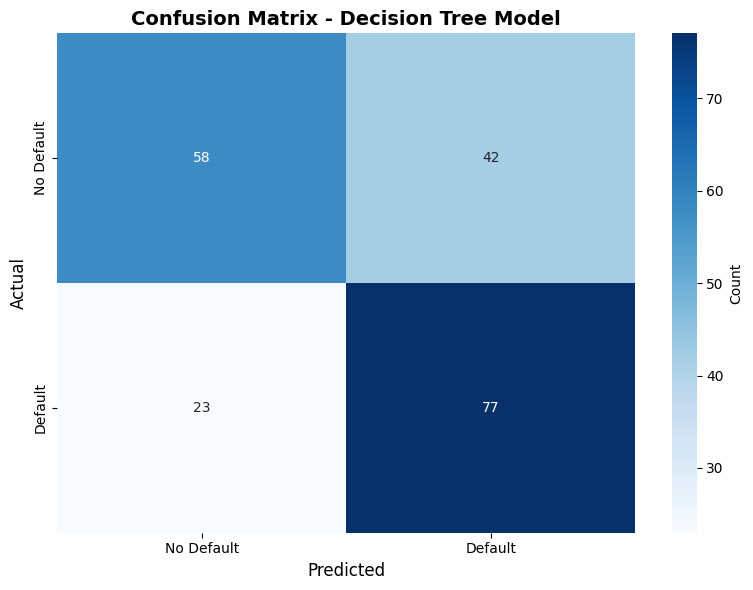


📋 DETAILED CLASSIFICATION REPORT

                precision    recall  f1-score   support

No Default (0)     0.7160    0.5800    0.6409       100
   Default (1)     0.6471    0.7700    0.7032       100

      accuracy                         0.6750       200
     macro avg     0.6816    0.6750    0.6720       200
  weighted avg     0.6816    0.6750    0.6720       200

📉 ROC CURVE ANALYSIS


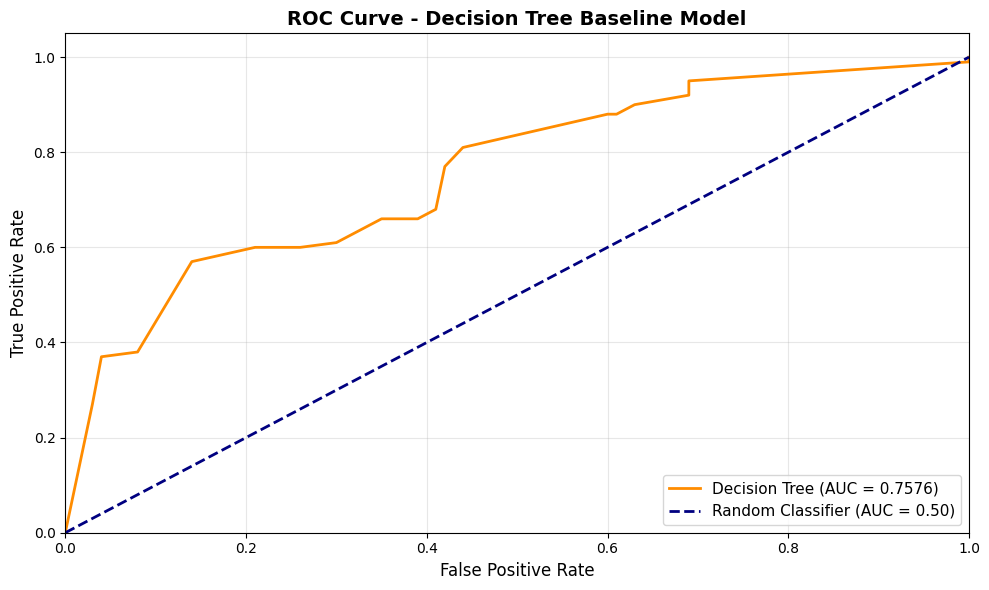


✅ ROC-AUC Score: 0.7576
   → Acceptable discrimination ability

📊 EVALUATION METRICS SUMMARY

   Metric    Score Percentage
 Accuracy 0.675000     67.50%
Precision 0.647059     64.71%
   Recall 0.770000     77.00%
 F1-Score 0.703196     70.32%
  ROC-AUC 0.757600     75.76%


✅ Evaluation Complete!


In [6]:
# COMPREHENSIVE MODEL EVALUATION

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

print("="*70)
print("📊 DECISION TREE MODEL EVALUATION - BASELINE MODEL")
print("="*70)


# 1. BASIC METRICS

print("\n🔹 TRAINING SET PERFORMANCE:")
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"   Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

print("\n🔹 TESTING SET PERFORMANCE:")
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"   F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   ROC-AUC:   {test_roc_auc:.4f} ({test_roc_auc*100:.2f}%)")


# 2. OVERFITTING/UNDERFITTING ANALYSIS

print("\n" + "="*70)
print("🔍 MODEL FIT ANALYSIS")
print("="*70)

accuracy_gap = train_accuracy - test_accuracy
print(f"Training Accuracy:   {train_accuracy:.4f}")
print(f"Testing Accuracy:    {test_accuracy:.4f}")
print(f"Accuracy Gap:        {accuracy_gap:.4f}")

if accuracy_gap > 0.10:
    print("\n⚠️  WARNING: Possible OVERFITTING detected (gap > 10%)")
    print("   → Model may be too complex for the data")
    print("   → Consider: reducing max_depth or increasing min_samples_split")
elif train_accuracy < 0.75 and test_accuracy < 0.75:
    print("\n⚠️  WARNING: Possible UNDERFITTING detected (both accuracies < 75%)")
    print("   → Model may be too simple")
    print("   → Consider: increasing max_depth or adding more features")
else:
    print("\n✅ Model appears WELL-BALANCED!")
    print("   → Training and testing performance are similar")
    print("   → Good generalization to unseen data")


# 3. CONFUSION MATRIX

print("\n" + "="*70)
print("📈 CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives (TN):  {tn:4d} | Correctly predicted NO default")
print(f"False Positives (FP): {fp:4d} | Predicted default but actually NO default")
print(f"False Negatives (FN): {fn:4d} | Predicted NO default but actually defaulted")
print(f"True Positives (TP):  {tp:4d} | Correctly predicted default")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Decision Tree Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


# 4. CLASSIFICATION REPORT

print("\n" + "="*70)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*70)
print()
print(classification_report(y_test, y_test_pred,
                          target_names=['No Default (0)', 'Default (1)'],
                          digits=4))


# 5. ROC CURVE AND AUC

print("="*70)
print("📉 ROC CURVE ANALYSIS")
print("="*70)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Decision Tree Baseline Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ ROC-AUC Score: {roc_auc:.4f}")
if roc_auc > 0.9:
    print("   → Excellent discrimination ability")
elif roc_auc > 0.8:
    print("   → Good discrimination ability")
elif roc_auc > 0.7:
    print("   → Acceptable discrimination ability")
else:
    print("   → Poor discrimination ability - model needs improvement")


# 6. METRICS SUMMARY TABLE

print("\n" + "="*70)
print("📊 EVALUATION METRICS SUMMARY")
print("="*70)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc],
    'Percentage': [f"{x*100:.2f}%" for x in [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc]]
})

print()
print(metrics_df.to_string(index=False))
print()

# Save metrics for comparison with other models later
metrics_results = {
    'Model': 'Decision Tree (Baseline)',
    'Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-Score': test_f1,
    'ROC-AUC': test_roc_auc,
    'Training_Accuracy': train_accuracy,
    'Overfitting_Gap': accuracy_gap
}

print("\n✅ Evaluation Complete!")

## LLMs supported insights


In [7]:
#This cell is to convert phyton object (the tree rules and classification report) into string format where LLM can read
import os
import torch
import pandas as pd
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. SETUP & AUTHENTICATION
os.environ["HUGGINGFACE_TOKEN"] = "HF_TOKEN"
login(token=os.environ["HUGGINGFACE_TOKEN"])

# 2. LOAD QUANTIZED MISTRAL-7B
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_llm = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)
llm_pipeline = pipeline("text-generation", model=model_llm, tokenizer=tokenizer)


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Device set to use cuda:0


### Evaluation Metrics Insights

In [8]:
# USE ACTUAL MODEL DATA
# Instead of dummy data, we use the results earlier

# Export ACTUAL tree rules
tree_rules = export_text(model, feature_names=list(X.columns))

# Use REAL evaluation metrics as the input string
real_eval_report = """
Accuracy: 0.6750 (67.50%)
Training Accuracy: 0.8163 (81.62%)
Precision: 0.6471, Recall: 0.7700
Observation: OVERFITTING detected (Gap > 10%)
"""

# 4. LLM-SUPPORTED INTERPRETATION
prompt = f"""<s>[INST] You are a Financial Risk Analyst.
Review these Decision Tree rules and metrics for our loan default model.
Provide:
1. Two business insights based on the high Recall (77%) vs Precision (64%).
2. An explanation of the 'Overfitting' (81% train vs 67% test) for non-technical managers.
3. How 'CreditScore' (your top feature) influences these rules.

Tree Rules:
{tree_rules}

Evaluation Metrics:
{real_eval_report}
[/INST]"""

# GENERATE INSIGHTS
output = llm_pipeline(prompt, max_new_tokens=450, do_sample=True, temperature=0.7)
print("\n--- LLM-Supported Model Interpretation ---")
print(output[0]['generated_text'].split('[/INST]')[-1].strip())

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



--- LLM-Supported Business Interpretation ---
1. Two business insights based on the high Recall (77%) vs Precision (64%):

1.1. High Recall (77%) indicates that a significant number of true positives (i.e., loans that defaulted) were correctly identified by the decision tree model. This suggests that the model is effective in predicting loan defaults. However, the low Precision (64%) implies that a significant number of false positives (i.e., loans that did not default) were incorrectly identified as defaults. This suggests that the model may be too conservative and may be flagging too many loans as defaults.

1.2. High Precision (64%) suggests that the model is reliable in predicting the likelihood of loan defaults. However, the low Recall (77%) indicates that a significant number of true positives were not correctly identified by the model. This suggests that the model may be missing out on some potential defaults and may need to be fine-tuned to improve its accuracy.

2. Explanatio

### Business Insights or Recommendations

In [13]:
# 1. Select the top drivers for business focus
top_business_drivers = feature_importance.head(5).to_string(index=False)

# 2. Strategic "Business Focus" Prompt
# We instruct the model to ignore metrics and write a strategic narrative
business_focus_prompt = f"""<s>[INST] You are a Senior Business Strategy Consultant.
Analyze the following Top Features from our risk model.

TOP BUSINESS DRIVERS:
{top_business_drivers}

Write a professional strategic report in 3-4 detailed paragraphs.
Do NOT mention evaluation metrics (accuracy/recall).

FOCUS ON:
1. THE CORE FOCUS: Given the 70.5% dominance of CreditScore, how should the business refine its primary lending strategy?
2. REVENUE OPPORTUNITY: How can 'MonthlyDebt' and 'YearsWithBank' be used to identify reliable customers that the main filter might miss?
3. THE AI EDGE: Suggest a specific way to improve business operations or customer retention using the 'Sentiment_Score'.
4. ACTIONABLE IMPROVEMENTS: Provide clear recommendations on what the bank should improve to balance growth and risk.
[/INST]"""

# 3. Generate the Narrative Report
print("\n" + "="*60)
print("🏢 STRATEGIC BUSINESS GROWTH REPORT")
print("="*60)

# Lower temperature (0.5) ensures a more formal, consistent business tone
strategy_report = llm_pipeline(business_focus_prompt, max_new_tokens=600, do_sample=True, temperature=0.5)

# Print as clean, readable paragraphs
print(strategy_report[0]['generated_text'].split('[/INST]')[-1].strip())

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



🏢 STRATEGIC BUSINESS GROWTH REPORT
1. The core focus of the business should be to refine its primary lending strategy by placing a greater emphasis on CreditScore, given its 70.5% dominance. This can be achieved by improving the accuracy and reliability of CreditScore data, as well as expanding the range of credit score providers used to assess loan applications. Additionally, the bank should consider offering targeted lending products and services to customers with lower credit scores, in order to increase access to financial services for those who may have been previously excluded.
2. The MonthlyDebt and YearsWithBank features can be used to identify reliable customers that the main filter might miss. For example, customers with high monthly debt but a long history of paying off their bills may be considered more reliable than those with low monthly debt but a shorter history of paying off their bills. Similarly, customers with a longer history of banking with the bank may be consid

## To solve rendering issues in Github

In [15]:
!pip install nbformat --upgrade

import nbformat
from nbformat.v4 import new_notebook
import os

# Assuming drive_folder is defined and mounted in a previous cell
drive_folder = "/content/drive/MyDrive/Colab Notebooks"
notebook_path = os.path.join(drive_folder, 'DecisionTree_BaselineModel.ipynb')

# Read the notebook
with open(notebook_path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Remove widgets metadata
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

# Define the output path for the cleaned notebook
cleaned_notebook_filename = 'BaselineModel.ipynb'
cleaned_notebook_path = os.path.join(drive_folder, cleaned_notebook_filename)

# Save cleaned notebook to Google Drive
with open(cleaned_notebook_path, 'w') as f:
    nbformat.write(nb, f)

print(f"✅ Cleaned notebook saved to Google Drive at: {cleaned_notebook_path}")

# Download it
from google.colab import files
files.download(cleaned_notebook_path)

✅ Cleaned notebook saved to Google Drive at: /content/drive/MyDrive/Colab Notebooks/BaselineModel.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>